In [ ]:
import sqlite3
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# Define the message types we expect
TOPIC_TYPES = {
    '/imu': 'sensor_msgs/msg/Imu',
    '/vio/odom': 'nav_msgs/msg/Odometry',
    '/ground_truth/odom': 'nav_msgs/msg/Odometry',
    '/tf': 'tf2_msgs/msg/TFMessage',
    '/tf_static': 'tf2_msgs/msg/TFMessage',
}

def analyze_bag(bag_path):
    # Connect to the SQLite3 database (.db3 file)
    try:
        conn = sqlite3.connect(bag_path)
        cursor = conn.cursor()
    except Exception as e:
        print(f"Error opening bag: {e}")
        return

    # Get topic IDs
    topics = {}
    for row in cursor.execute("SELECT id, name, type FROM topics"):
        topics[row[0]] = {'name': row[1], 'type': row[2]}

    # Data containers
    imu_data = {'timestamps': [], 'acc_x': [], 'acc_y': [], 'acc_z': [], 'gyro_x': [], 'gyro_y': [], 'gyro_z': []}
    vio_path = {'x': [], 'y': [], 'timestamps': []}
    gt_path = {'x': [], 'y': [], 'timestamps': []}
    tf_messages = []
    tf_static_messages = []

    print(f"Reading bag: {bag_path}...")
    print("topics found:")
    for topic_id, info in topics.items():
        print(f"  ID {topic_id}: {info['name']} ({info['type']})")

    # Read messages
    for row in cursor.execute("SELECT topic_id, timestamp, data FROM messages"):
        topic_id = row[0]
        timestamp = row[1]
        data = row[2]

        topic_name = topics[topic_id]['name']
        topic_type = topics[topic_id]['type']

        # Instantiate the message class
        msg_class = get_message(topic_type)
        msg = deserialize_message(data, msg_class)

        if topic_name == '/imu':
            imu_data['timestamps'].append(timestamp)
            imu_data['acc_x'].append(msg.linear_acceleration.x)
            imu_data['acc_y'].append(msg.linear_acceleration.y)
            imu_data['acc_z'].append(msg.linear_acceleration.z)
            imu_data['gyro_x'].append(msg.angular_velocity.x)
            imu_data['gyro_y'].append(msg.angular_velocity.y)
            imu_data['gyro_z'].append(msg.angular_velocity.z)

        elif topic_name == '/vio/odom':
            vio_path['x'].append(msg.pose.pose.position.x)
            vio_path['y'].append(msg.pose.pose.position.y)
            vio_path['timestamps'].append(timestamp)

        elif topic_name == '/ground_truth/odom':
            gt_path['x'].append(msg.pose.pose.position.x)
            gt_path['y'].append(msg.pose.pose.position.y)
            gt_path['timestamps'].append(timestamp)

        elif topic_name == '/tf':
            tf_messages.append({'index': len(tf_messages), 'timestamp': timestamp, 'msg': msg})

        elif topic_name == '/tf_static':
            tf_static_messages.append({'index': len(tf_static_messages), 'timestamp': timestamp, 'msg': msg})

    conn.close()

    # --- ANALYSIS ---
    print("\n=== ANALYSIS REPORT ===")

    # 1. IMU Gravity Check
    if imu_data['acc_z']:
        avg_z = np.mean(imu_data['acc_z'])
        print(f"[IMU] Average Z-Accel: {avg_z:.4f} m/s^2")
        if 9.0 < abs(avg_z) < 10.5:
            print("      -> PASSED: Gravity looks normal (near 9.8).")
        else:
            print("      -> FAILED: Gravity is weird! Check IMU orientation in URDF.")
    else:
        print("[IMU] No IMU data found!")

    # 2. TF and TF_Static Analysis
    print("\n=== TF_STATIC HEAD (first 5 messages) ===")
    print(f"Total tf_static messages: {len(tf_static_messages)}")
    print(f"Data type: {type(tf_static_messages[0]['msg']) if tf_static_messages else 'N/A'}")
    for i, tf_msg in enumerate(tf_static_messages[:5]):
        print(f"\n[Index {tf_msg['index']}] Timestamp: {tf_msg['timestamp']}")
        for transform in tf_msg['msg'].transforms:
            print(f"  Frame: {transform.header.frame_id} -> {transform.child_frame_id}")
            print(f"    Translation: ({transform.transform.translation.x:.4f}, {transform.transform.translation.y:.4f}, {transform.transform.translation.z:.4f})")
            print(f"    Rotation: ({transform.transform.rotation.x:.4f}, {transform.transform.rotation.y:.4f}, {transform.transform.rotation.z:.4f}, {transform.transform.rotation.w:.4f})")

    print("\n=== TF HEAD (first 5 messages) ===")
    print(f"Total tf messages: {len(tf_messages)}")
    print(f"Data type: {type(tf_messages[0]['msg']) if tf_messages else 'N/A'}")
    for i, tf_msg in enumerate(tf_messages[:5]):
        print(f"\n[Index {tf_msg['index']}] Timestamp: {tf_msg['timestamp']}")
        for transform in tf_msg['msg'].transforms:
            print(f"  Frame: {transform.header.frame_id} -> {transform.child_frame_id}")
            print(f"    Translation: ({transform.transform.translation.x:.4f}, {transform.transform.translation.y:.4f}, {transform.transform.translation.z:.4f})")
            print(f"    Rotation: ({transform.transform.rotation.x:.4f}, {transform.transform.rotation.y:.4f}, {transform.transform.rotation.z:.4f}, {transform.transform.rotation.w:.4f})")

    # 3. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Ground Truth vs VIO Trajectory
    ax1 = axes[0, 0]
    if gt_path['x']:
        ax1.plot(gt_path['x'], gt_path['y'], 'g-', label='Ground Truth', linewidth=2)
    if vio_path['x']:
        ax1.plot(vio_path['x'], vio_path['y'], 'r--', label='VIO Estimate', linewidth=1)
    ax1.set_title("Ground Truth vs VIO Trajectory")
    ax1.set_xlabel("X Position (m)")
    ax1.set_ylabel("Y Position (m)")
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')

    # Plot 2: IMU Accelerations
    ax2 = axes[0, 1]
    if imu_data['timestamps']:
        t_imu = np.array(imu_data['timestamps']) * 1e-9  # Convert to seconds
        t_imu = t_imu - t_imu[0]  # Start from 0
        ax2.plot(t_imu, imu_data['acc_x'], 'r-', label='Acc X', alpha=0.7)
        ax2.plot(t_imu, imu_data['acc_y'], 'g-', label='Acc Y', alpha=0.7)
        ax2.plot(t_imu, imu_data['acc_z'], 'b-', label='Acc Z', alpha=0.7)
    ax2.set_title("IMU Linear Accelerations")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Acceleration (m/s²)")
    ax2.legend()
    ax2.grid(True)

    # Plot 3: IMU Gyroscope
    ax3 = axes[1, 0]
    if imu_data['timestamps']:
        ax3.plot(t_imu, imu_data['gyro_x'], 'r-', label='Gyro X', alpha=0.7)
        ax3.plot(t_imu, imu_data['gyro_y'], 'g-', label='Gyro Y', alpha=0.7)
        ax3.plot(t_imu, imu_data['gyro_z'], 'b-', label='Gyro Z', alpha=0.7)
    ax3.set_title("IMU Angular Velocities")
    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Angular Velocity (rad/s)")
    ax3.legend()
    ax3.grid(True)

    # Plot 4: Position over time
    ax4 = axes[1, 1]
    if gt_path['timestamps']:
        t_gt = np.array(gt_path['timestamps']) * 1e-9
        t_gt = t_gt - t_gt[0]
        ax4.plot(t_gt, gt_path['x'], 'g-', label='GT X', linewidth=2)
        ax4.plot(t_gt, gt_path['y'], 'g--', label='GT Y', linewidth=2)
    if vio_path['timestamps']:
        t_vio = np.array(vio_path['timestamps']) * 1e-9
        t_vio = t_vio - t_vio[0]
        ax4.plot(t_vio, vio_path['x'], 'r-', label='VIO X', linewidth=1, alpha=0.7)
        ax4.plot(t_vio, vio_path['y'], 'r--', label='VIO Y', linewidth=1, alpha=0.7)
    ax4.set_title("Position vs Time")
    ax4.set_xlabel("Time (s)")
    ax4.set_ylabel("Position (m)")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    print("\nOpening plot window...")
    plt.show()


Reading bag: /workspaces/585_Probabilistic_Robotics/sanity_check/sanity_check_0.db3...
topics found:
  ID 1: /vio/odom (nav_msgs/msg/Odometry)
  ID 2: /tf_static (tf2_msgs/msg/TFMessage)
  ID 3: /imu (sensor_msgs/msg/Imu)
  ID 4: /tf (tf2_msgs/msg/TFMessage)
  ID 5: /ground_truth/odom (nav_msgs/msg/Odometry)

=== ANALYSIS REPORT ===
[IMU] Average Z-Accel: 9.7996 m/s^2
      -> PASSED: Gravity looks normal (near 9.8).

Opening plot window...


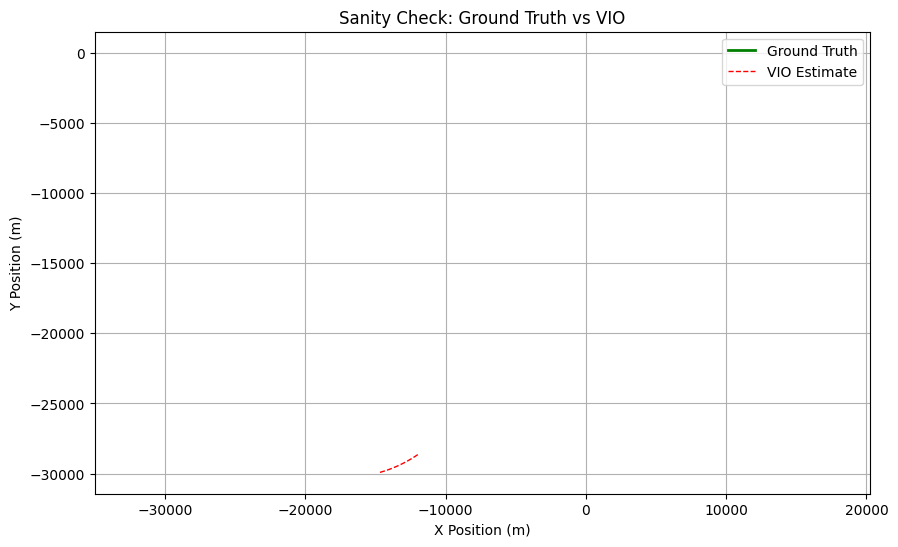

In [2]:
bag_path = "/workspaces/585_Probabilistic_Robotics/sanity_check/sanity_check_0.db3"
analyze_bag(bag_path)